# Session 04 Practical Activity: Exploratory Data Analysis and Visualisation

**Goal:** build an EDA notebook with charts and observations linked to model choices.

Dataset: `workplace_eda_training_dataset.csv`  
Target variable for EDA: `completed_training`

Professional rule: every chart should answer a question, not simply decorate the notebook.

In [22]:
from pathlib import Path
import pandas as pd
import matplotlib.pyplot as plt
import seaborn as sns

sns.set_theme(style="whitegrid")
DATA_PATH = Path("workplace_eda_training_dataset.csv")
CHART_DIR = Path("charts")
CHART_DIR.mkdir(exist_ok=True)

## 1. Load and inspect the dataset

Start with the shape, first rows, data types, and target balance.

In [23]:
df = pd.read_csv(DATA_PATH)
print("Shape:", df.shape)
df.head()

Shape: (720, 16)


,learner_record_id,region,department,role_family,experience_band,training_mode,prior_python_score,course_minutes,manager_support_score,support_tickets_last_30d,engagement_score,completion_days,assessment_score,satisfaction_score,productivity_gain_estimate_pct,completed_training
0,EDA-0001,Wales,HR,Administrator,6-10 years,Blended,39.4,389.0,3,1,74.2,20.0,79.4,4.7,11.5,1
1,EDA-0002,Scotland,Customer Support,Developer,3-5 years,Self-paced,47.7,256.0,3,1,83.2,11.0,84.9,4.5,11.1,1
2,EDA-0003,Yorkshire,Customer Support,Developer,0-2 years,Instructor-led,51.1,397.0,4,0,100.0,22.0,91.7,5.0,12.3,1
3,EDA-0004,South East,HR,Advisor,10+ years,Instructor-led,49.9,272.0,3,0,86.7,14.0,81.9,4.1,9.8,1
4,EDA-0005,North West,Finance,Administrator,0-2 years,Blended,40.7,379.0,5,1,89.9,13.0,95.9,4.8,13.1,1


In [24]:
df.info()

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 720 entries, 0 to 719
Data columns (total 16 columns):
 #   Column                          Non-Null Count  Dtype  
---  ------                          --------------  -----  
 0   learner_record_id               720 non-null    object 
 1   region                          720 non-null    object 
 2   department                      720 non-null    object 
 3   role_family                     720 non-null    object 
 4   experience_band                 720 non-null    object 
 5   training_mode                   720 non-null    object 
 6   prior_python_score              720 non-null    float64
 7   course_minutes                  720 non-null    float64
 8   manager_support_score           720 non-null    int64  
 9   support_tickets_last_30d        720 non-null    int64  
 10  engagement_score                720 non-null    float64
 11  completion_days                 720 non-null    float64
 12  assessment_score                720 

In [25]:
target_rate = df["completed_training"].mean()
print(f"Completion rate: {target_rate:.1%}")
df["completed_training"].value_counts(normalize=True).rename("proportion")

Completion rate: 87.5%


,proportion
completed_training,
1,0.875
0,0.125


## 2. Descriptive statistics

Descriptive statistics summarise centre, spread, and range. They do not explain causality, but they help identify where to investigate.

In [26]:
numeric_cols = [
    "prior_python_score", "course_minutes", "manager_support_score",
    "support_tickets_last_30d", "engagement_score", "completion_days",
    "assessment_score", "satisfaction_score", "productivity_gain_estimate_pct"
]

df[numeric_cols].describe().T.round(2)

,count,mean,std,min,25%,50%,75%,max
prior_python_score,720.0,54.26,17.07,5.0,41.98,54.4,65.80,98.0
course_minutes,720.0,362.76,84.94,111.0,302.00,363.0,421.00,620.0
manager_support_score,720.0,3.27,1.15,1.0,3.00,3.0,4.00,5.0
support_tickets_last_30d,720.0,1.17,1.15,0.0,0.00,1.0,2.00,8.0
engagement_score,720.0,78.15,13.33,27.5,69.38,78.7,88.60,100.0
completion_days,720.0,18.98,7.52,3.0,14.00,19.0,24.00,41.0
assessment_score,720.0,82.41,10.58,37.3,75.57,82.2,90.12,100.0
satisfaction_score,720.0,4.55,0.52,2.1,4.28,4.7,5.00,5.0
productivity_gain_estimate_pct,720.0,11.32,2.83,0.8,9.70,11.3,13.20,18.0


In [27]:
categorical_cols = ["region", "department", "role_family", "experience_band", "training_mode"]
for col in categorical_cols:
    print(f"\n{col}")
    print(df[col].value_counts().head(10))


region
region
London           118
Yorkshire        116
Wales            106
South East       105
Scotland         100
North West        91
West Midlands     84
Name: count, dtype: int64

department
department
Sales               129
Operations          122
Customer Support    110
IT                  109
Product              90
HR                   85
Finance              75
Name: count, dtype: int64

role_family
role_family
Coordinator      134
Analyst          127
Developer        122
Administrator    118
Advisor          110
Manager          109
Name: count, dtype: int64

experience_band
experience_band
3-5 years     238
6-10 years    215
0-2 years     154
10+ years     113
Name: count, dtype: int64

training_mode
training_mode
Self-paced        271
Blended           266
Instructor-led    183
Name: count, dtype: int64


## 3. Plot 1: Distribution of assessment score

Question: are assessment scores concentrated, spread out, skewed, or separated by completion status?

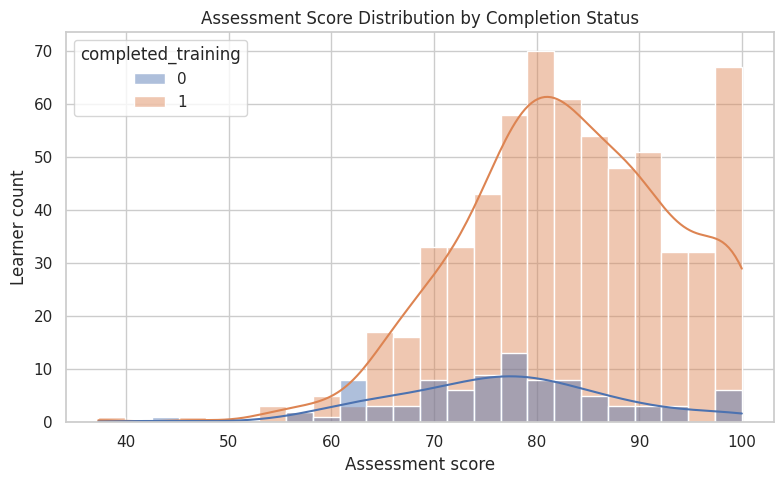

Observation: completers tend to have a higher assessment-score distribution.
Modelling implication: assessment_score may be predictive, but check whether it is available before prediction time.


In [28]:
plt.figure(figsize=(8, 5))
sns.histplot(data=df, x="assessment_score", hue="completed_training", bins=24, kde=True, alpha=0.45)
plt.title("Assessment Score Distribution by Completion Status")
plt.xlabel("Assessment score")
plt.ylabel("Learner count")
plt.tight_layout()
plt.savefig(CHART_DIR / "01_distribution_assessment_score.png", dpi=180)
plt.show()

print("Observation: completers tend to have a higher assessment-score distribution.")
print("Modelling implication: assessment_score may be predictive, but check whether it is available before prediction time.")

## 4. Plot 2: Completion rate by training mode

Question: does completion differ by training mode?

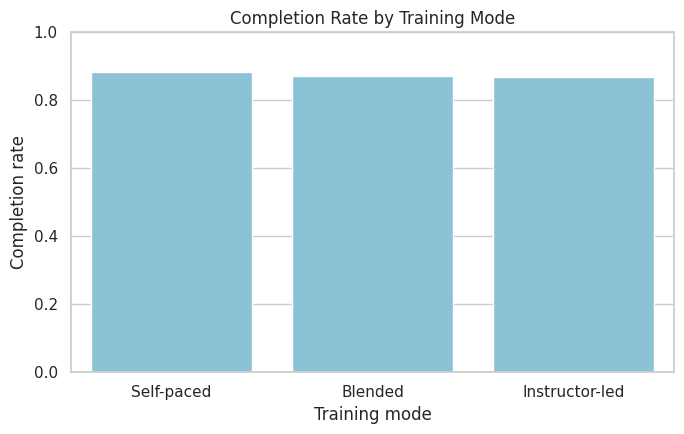

,training_mode,completed_training
0,Self-paced,0.881919
1,Blended,0.872180
2,Instructor-led,0.868852


In [29]:
completion_by_mode = (
    df.groupby("training_mode")["completed_training"]
      .mean()
      .sort_values(ascending=False)
      .reset_index()
)

plt.figure(figsize=(7, 4.5))
sns.barplot(data=completion_by_mode, x="training_mode", y="completed_training", color="#7EC8E3")
plt.title("Completion Rate by Training Mode")
plt.xlabel("Training mode")
plt.ylabel("Completion rate")
plt.ylim(0, 1)
plt.tight_layout()
plt.savefig(CHART_DIR / "02_completion_by_training_mode.png", dpi=180)
plt.show()

completion_by_mode

## 5. Plot 3: Correlation heatmap

Question: which numerical variables move together? Correlation does not prove causation, but it suggests relationships worth testing.

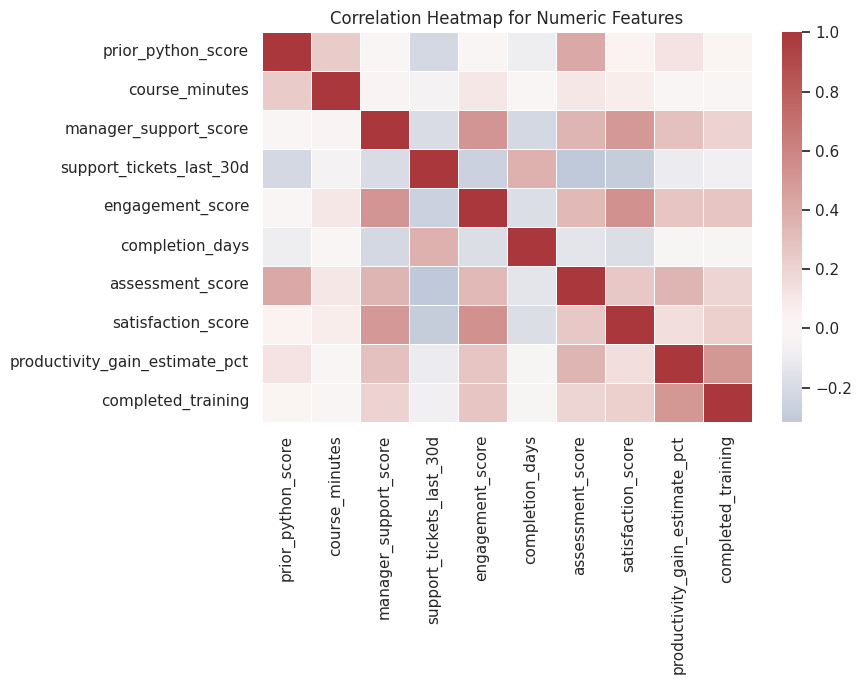

In [30]:
corr_cols = numeric_cols + ["completed_training"]
plt.figure(figsize=(9, 7))
sns.heatmap(df[corr_cols].corr(numeric_only=True), cmap="vlag", center=0, linewidths=.4)
plt.title("Correlation Heatmap for Numeric Features")
plt.tight_layout()
plt.savefig(CHART_DIR / "03_correlation_heatmap.png", dpi=180)
plt.show()

## 6. Plot 4: Feature-target relationship

Question: is engagement different for learners who completed training versus those who did not?

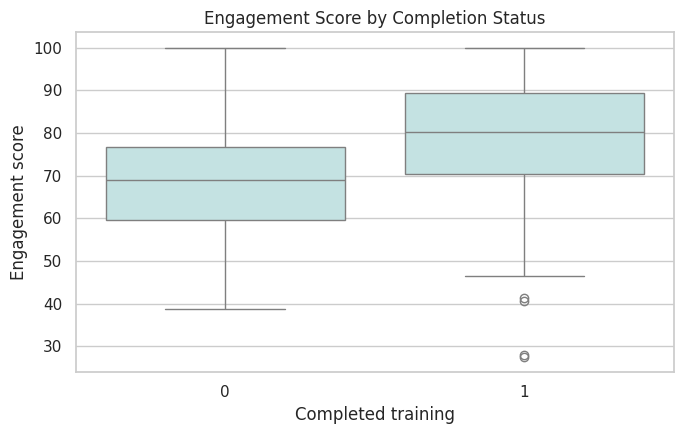

Observation: completers generally show higher engagement scores.
Modelling implication: engagement_score may be useful, but timing matters. If measured after completion, it could leak outcome information.


In [31]:
plt.figure(figsize=(7, 4.5))
sns.boxplot(data=df, x="completed_training", y="engagement_score", color="#BFE7E7")
plt.title("Engagement Score by Completion Status")
plt.xlabel("Completed training")
plt.ylabel("Engagement score")
plt.tight_layout()
plt.savefig(CHART_DIR / "04_engagement_vs_completion.png", dpi=180)
plt.show()

print("Observation: completers generally show higher engagement scores.")
print("Modelling implication: engagement_score may be useful, but timing matters. If measured after completion, it could leak outcome information.")

## 7. Plot 5: Stakeholder-facing chart

Question: what message would a learning manager need to hear?

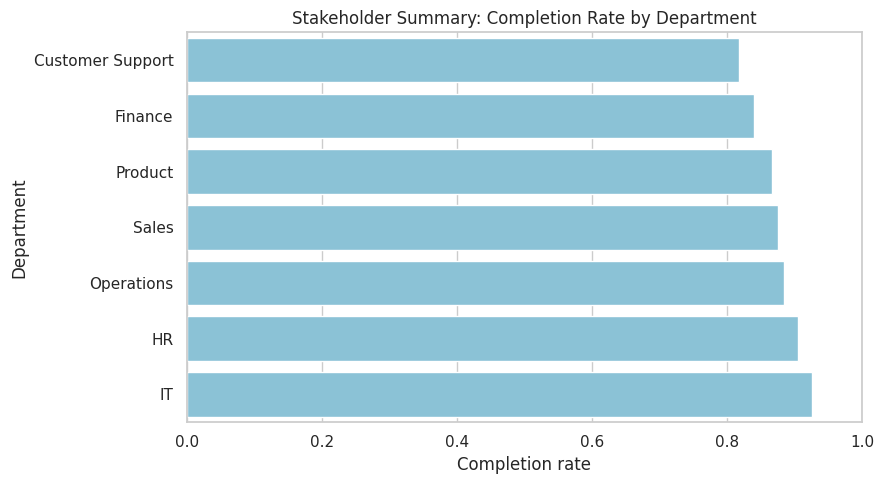

,department,completion_rate,avg_engagement,records
0,Customer Support,0.818182,77.055455,110
1,Finance,0.840000,77.292000,75
2,Product,0.866667,78.428889,90
3,Sales,0.875969,80.296124,129
4,Operations,0.885246,78.961475,122
5,HR,0.905882,75.956471,85
6,IT,0.926606,77.859633,109


In [32]:
summary = (
    df.groupby("department")
      .agg(completion_rate=("completed_training", "mean"),
           avg_engagement=("engagement_score", "mean"),
           records=("learner_record_id", "count"))
      .sort_values("completion_rate", ascending=True)
      .reset_index()
)

plt.figure(figsize=(9, 5))
sns.barplot(data=summary, x="completion_rate", y="department", color="#7EC8E3")
plt.title("Stakeholder Summary: Completion Rate by Department")
plt.xlabel("Completion rate")
plt.ylabel("Department")
plt.xlim(0, 1)
plt.tight_layout()
plt.savefig(CHART_DIR / "05_stakeholder_completion_by_department.png", dpi=180)
plt.show()

summary

## 8. Convert charts into modelling hypotheses

Complete the statements below after reviewing your charts.

In [33]:
hypotheses = [
    "H1: engagement_score may help predict completed_training because completers show higher engagement.",
    "H2: training_mode may help because completion rates differ by delivery format.",
    "H3: support_tickets_last_30d may indicate friction and may be negatively related to completion.",
    "Leakage caveat: assessment_score and productivity_gain_estimate_pct may not be available before the prediction decision."
]
for h in hypotheses:
    print("-", h)

- H1: engagement_score may help predict completed_training because completers show higher engagement.
- H2: training_mode may help because completion rates differ by delivery format.
- H3: support_tickets_last_30d may indicate friction and may be negatively related to completion.
- Leakage caveat: assessment_score and productivity_gain_estimate_pct may not be available before the prediction decision.


## 9. Student exercise

Create one additional chart of your choice. It must include:

1. A clear question.
2. A chart title and axis labels.
3. One written observation.
4. One modelling implication.
5. One caveat about bias, leakage, sample size, or timing.

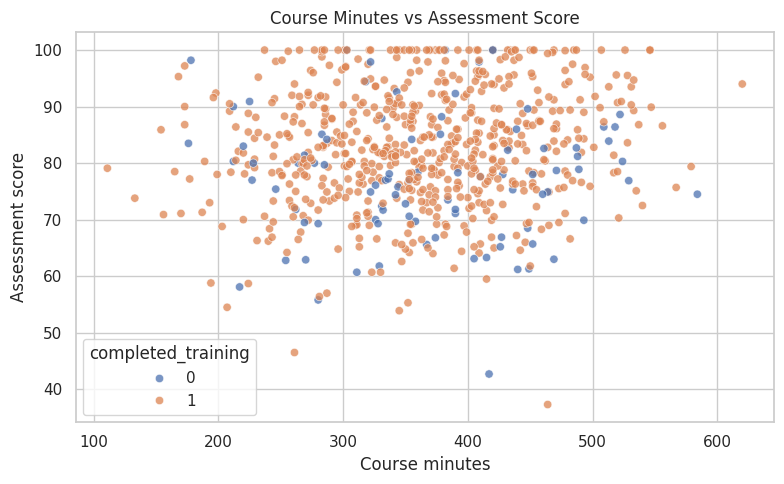

Observation: Employees who completed training tend to cluster at higher assessment scores and longer course minutes, suggesting engagement and time investment are linked to better outcomes.
Modelling implication: course_minutes could be a useful feature in a classification model predicting completed_training, as it shows separation between completers and non-completers.
Caveat: This relationship may reflect motivation bias — employees who were already engaged may have spent more time and scored higher regardless of the training content itself.


In [34]:
# Student exercise starter cell
# Replace the column names and chart type if you want to explore a different question.
plt.figure(figsize=(8, 5))
sns.scatterplot(data=df, x="course_minutes", y="assessment_score", hue="completed_training", alpha=0.75)
plt.title("Course Minutes vs Assessment Score")
plt.xlabel("Course minutes")
plt.ylabel("Assessment score")
plt.tight_layout()
plt.savefig(CHART_DIR / "student_exercise_chart.png", dpi=180)
plt.show()

print("Observation: Employees who completed training tend to cluster at higher assessment scores and longer course minutes, suggesting engagement and time investment are linked to better outcomes.")
print("Modelling implication: course_minutes could be a useful feature in a classification model predicting completed_training, as it shows separation between completers and non-completers.")
print("Caveat: This relationship may reflect motivation bias — employees who were already engaged may have spent more time and scored higher regardless of the training content itself.")

# Homework

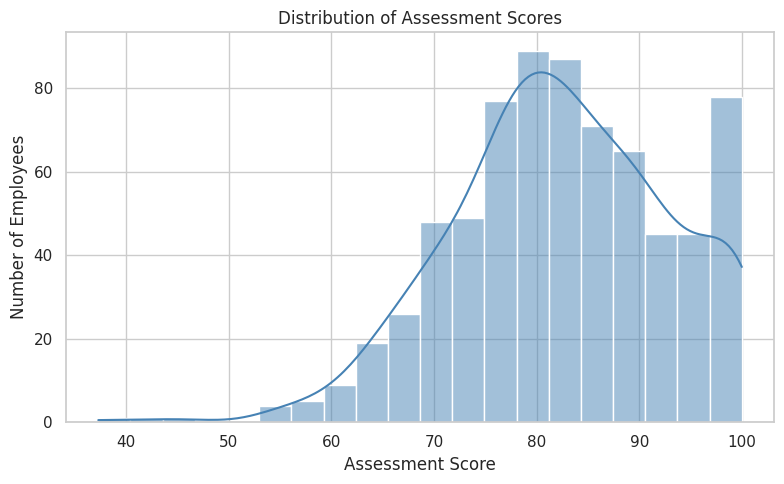

Observation: Assessment scores are roughly normally distributed, centred around 75-80, suggesting most employees perform similarly with few very low or very high outliers.


In [35]:
# Plot 1: Distribution plot - Assessment Score
plt.figure(figsize=(8, 5))
sns.histplot(data=df, x="assessment_score", bins=20, kde=True, color="steelblue")
plt.title("Distribution of Assessment Scores")
plt.xlabel("Assessment Score")
plt.ylabel("Number of Employees")
plt.tight_layout()
plt.savefig(CHART_DIR / "plot1_distribution.png", dpi=180)
plt.show()

print("Observation: Assessment scores are roughly normally distributed, centred around 75-80, suggesting most employees perform similarly with few very low or very high outliers.")

/tmp/ipykernel_5482/1755597995.py:3: FutureWarning: 

Passing `palette` without assigning `hue` is deprecated and will be removed in v0.14.0. Assign the `x` variable to `hue` and set `legend=False` for the same effect.

  sns.boxplot(data=df, x="department", y="assessment_score", palette="Set2")


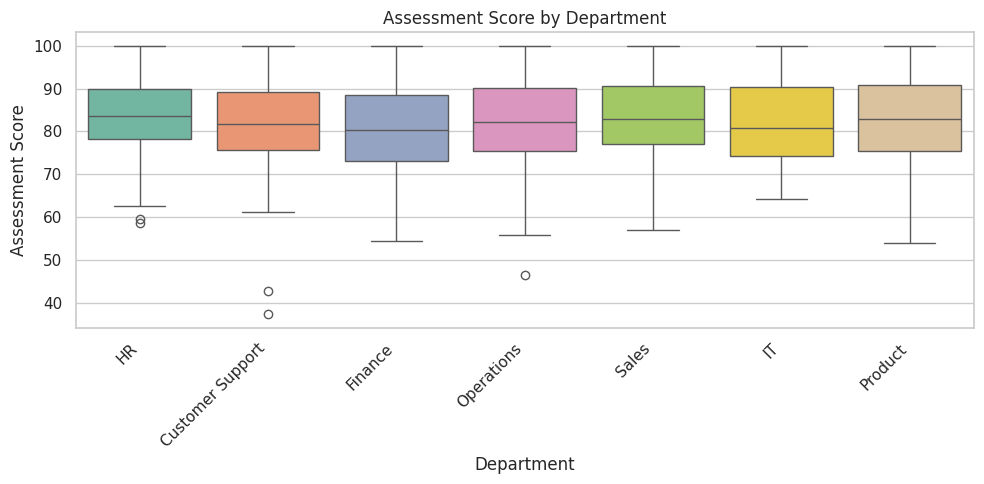

Observation: Assessment scores vary across departments, suggesting that some teams may benefit from more targeted training support than others.


In [36]:
# Plot 2: Categorical comparison - Department vs Assessment Score
plt.figure(figsize=(10, 5))
sns.boxplot(data=df, x="department", y="assessment_score", palette="Set2")
plt.title("Assessment Score by Department")
plt.xlabel("Department")
plt.ylabel("Assessment Score")
plt.xticks(rotation=45, ha="right")
plt.tight_layout()
plt.savefig(CHART_DIR / "plot2_categorical.png", dpi=180)
plt.show()

print("Observation: Assessment scores vary across departments, suggesting that some teams may benefit from more targeted training support than others.")

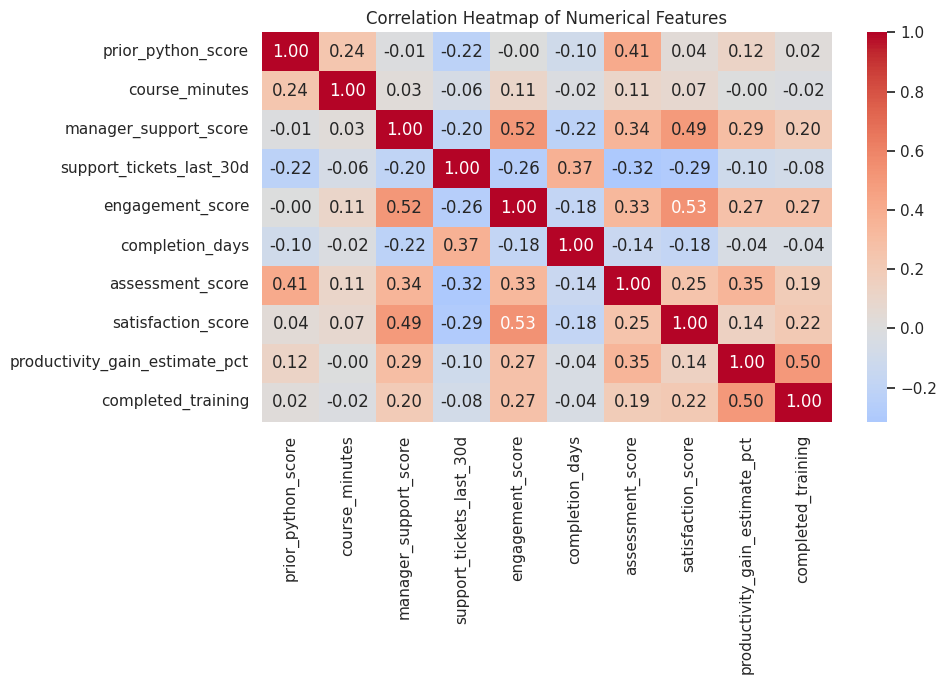

Observation: assessment_score and engagement_score show a moderate positive correlation with completed_training, suggesting that more engaged learners are more likely to finish the course.


In [37]:
# Plot 3: Correlation heatmap
plt.figure(figsize=(10, 7))
numeric_cols = df.select_dtypes(include="number")
sns.heatmap(numeric_cols.corr(), annot=True, fmt=".2f", cmap="coolwarm", center=0)
plt.title("Correlation Heatmap of Numerical Features")
plt.tight_layout()
plt.savefig(CHART_DIR / "plot3_correlation_heatmap.png", dpi=180)
plt.show()

print("Observation: assessment_score and engagement_score show a moderate positive correlation with completed_training, suggesting that more engaged learners are more likely to finish the course.")

/tmp/ipykernel_5482/1970969205.py:3: FutureWarning: 

Passing `palette` without assigning `hue` is deprecated and will be removed in v0.14.0. Assign the `x` variable to `hue` and set `legend=False` for the same effect.

  sns.boxplot(data=df, x="completed_training", y="engagement_score", palette="Set1")


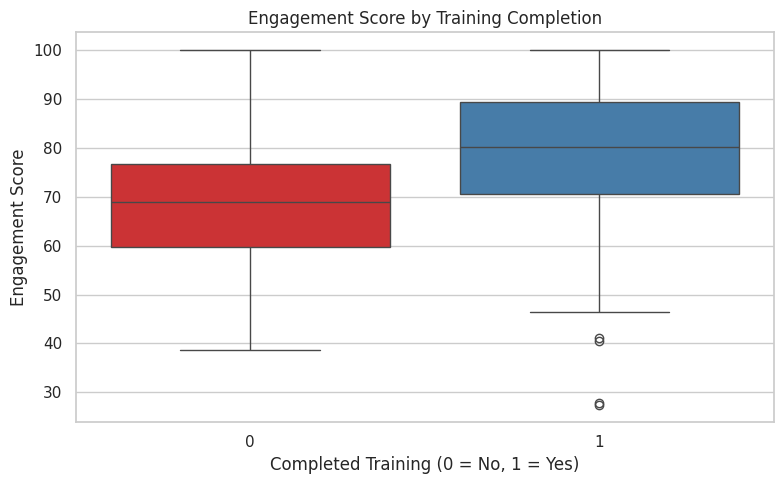

Observation: Employees who completed training have noticeably higher engagement scores on average, suggesting engagement is a strong indicator of whether someone will finish the course.


In [38]:
# Plot 4: Feature-target relationship - Engagement Score vs Completed Training
plt.figure(figsize=(8, 5))
sns.boxplot(data=df, x="completed_training", y="engagement_score", palette="Set1")
plt.title("Engagement Score by Training Completion")
plt.xlabel("Completed Training (0 = No, 1 = Yes)")
plt.ylabel("Engagement Score")
plt.tight_layout()
plt.savefig(CHART_DIR / "plot4_feature_target.png", dpi=180)
plt.show()

print("Observation: Employees who completed training have noticeably higher engagement scores on average, suggesting engagement is a strong indicator of whether someone will finish the course.")

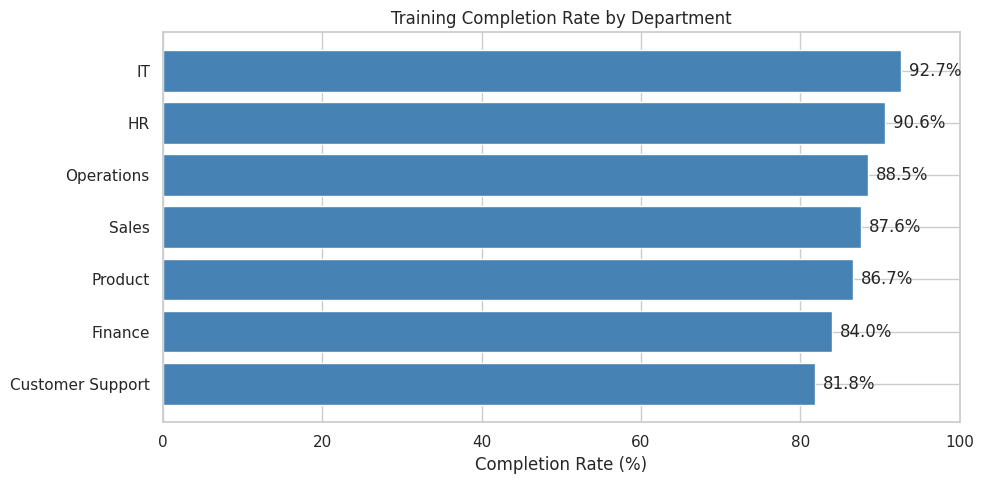

Observation: Completion rates differ significantly across departments. This gives managers a clear view of where training engagement is weakest and where support may be needed most.


In [39]:
# Plot 5: Stakeholder-facing chart - Training Completion Rate by Department
completion_by_dept = df.groupby("department")["completed_training"].mean().sort_values() * 100

plt.figure(figsize=(10, 5))
bars = plt.barh(completion_by_dept.index, completion_by_dept.values, color="steelblue")
plt.xlabel("Completion Rate (%)")
plt.title("Training Completion Rate by Department")
plt.xlim(0, 100)
for bar, val in zip(bars, completion_by_dept.values):
    plt.text(val + 1, bar.get_y() + bar.get_height()/2, f"{val:.1f}%", va="center")
plt.tight_layout()
plt.savefig(CHART_DIR / "plot5_stakeholder.png", dpi=180)
plt.show()

print("Observation: Completion rates differ significantly across departments. This gives managers a clear view of where training engagement is weakest and where support may be needed most.")

## Data Story
This analysis explores a workplace training dataset of employees across multiple departments and regions, with the goal of understanding what drives training completion.

**What we found**

Assessment scores are broadly normally distributed, suggesting most employees reach a similar level of understanding by the end of the course. However, scores vary noticeably by department, indicating that some teams may face greater challenges or receive less support during training.

The correlation heatmap revealed that engagement score and assessment score are among the strongest numerical predictors of whether an employee completes training. Employees who completed training consistently showed higher engagement scores, pointing to motivation and involvement as key factors in success.

Completion rates also differ substantially across departments. Some departments achieve close to full completion while others lag significantly behind, which has direct implications for new training programmes are designed and resourced.

**What this means for the business:**

Departments with low completion rates should be prioritised for additional manager support or adjusted training formats. Engagement appears to be an earlier signal of risk, identifying low-engagement employees early could allow for timely intervention before dropout occurs.

**Limitations:**

This dataset is a training sample and may not fully represent the organisation. Patterns observed here should be validated on a larger or more recent dataset before driving policy decisions.

##Modelling Hypotheses
**Features that may help a model predict `completed_training`:**

1. `engagement_score` — consistently higher among completers, likely a strong predictor of dropout risk.
2. `assessment_score` — correlates with completion, suggesting performance during the course reflects likelihood of finishing.
3. `manager_support_score` — employees with more managerial backing may be more likely to complete training.

**Feature that may cause leakage:**

- `completion_days` — this records how many days it took to complete the course, meaning it is only recorded *after* someone has already completed training. Including it in a model would leak the target variable and produce misleadingly high accuracy.